In [6]:
# Google Drive mount

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

def set_default_directory(directory):
    """
    기본 작업 디렉토리를 설정하는 함수
    """
    os.chdir(directory)
    print("현재 작업 디렉토리를 설정했습니다:", os.getcwd())

In [8]:
# ipynb 파일이 있는 위치로 경로 설정
drive_path = '/content/drive/MyDrive/chapter14'
set_default_directory(drive_path)

현재 작업 디렉토리를 설정했습니다: /content/drive/MyDrive/chapter14


# SIFT Descriptor

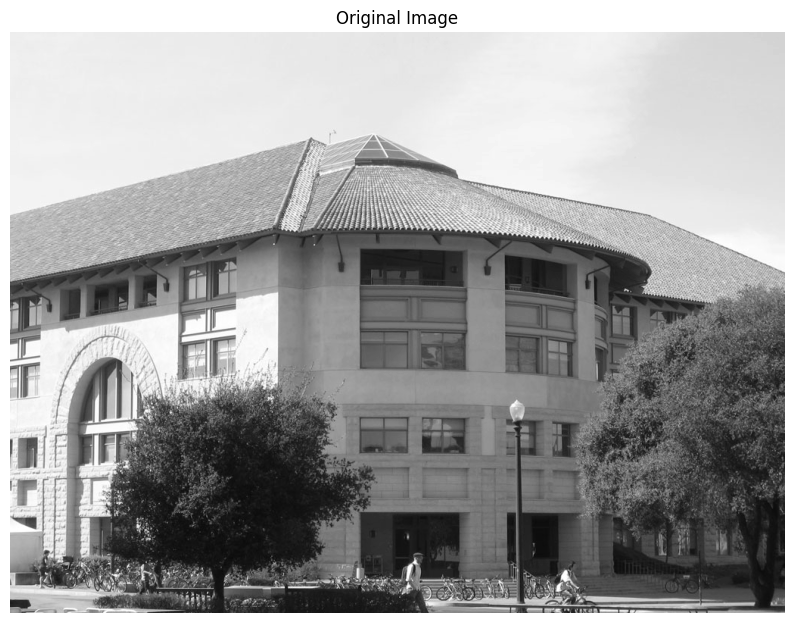

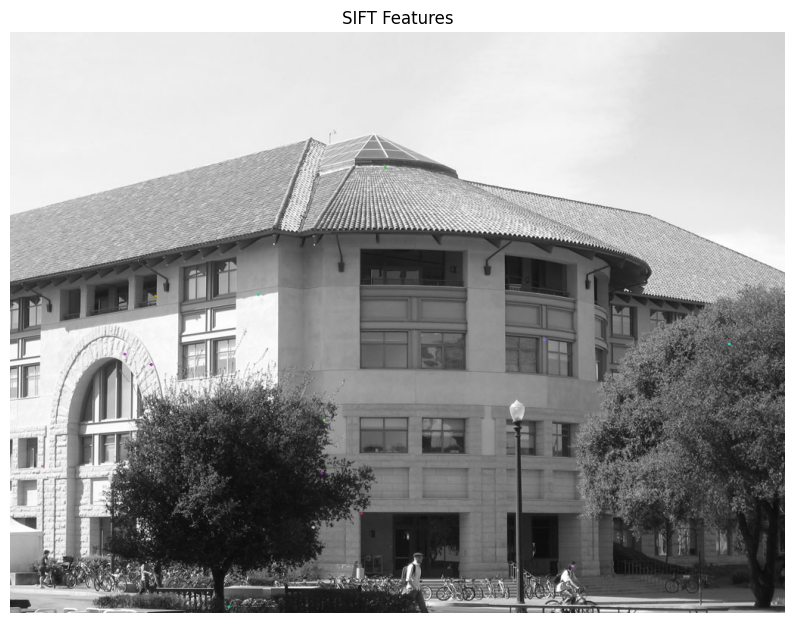

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지를 로드하고 그레이스케일로 변환
img = cv2.imread('gates.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

# SIFT 특징점과 기술자 추출
# contrastThreshold 값을 낮춥니다.
sift = cv2.SIFT_create(contrastThreshold=0.04)  # 예를 들어, 기본값 또는 더 낮은 값 사용
keypoints, descriptors = sift.detectAndCompute(img, None)

# 검출된 특징점이 충분한지 확인합니다.
if len(keypoints) > 0:
    # 선택된 특징점 시각화 (랜덤하게 15개 선택 또는 가능한 경우 그 이하)
    num_to_select = min(15, len(keypoints))  # 15개 또는 더 적은 특징점 사용
    indices = np.random.choice(len(keypoints), num_to_select, replace=False)
    selected_keypoints = [keypoints[i] for i in indices]

    # 특징점 시각화
    img_keypoints = cv2.drawKeypoints(img, selected_keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_keypoints)
    plt.title('SIFT Features')
    plt.axis('off')
    plt.show()
else:
    print("검출된 특징점이 없습니다. contrastThreshold 값을 조정해 보세요.")



# RANSAC

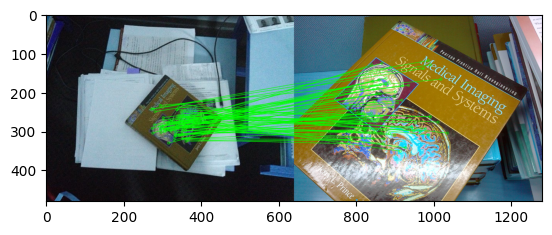

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sift_mosaic(im1, im2):
    # Convert images to grayscale
    im1_gray = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
    im2_gray = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

    # Initialize SIFT detector
    sift = cv2.SIFT_create()

    # Find keypoints and descriptors with SIFT
    kp1, des1 = sift.detectAndCompute(im1_gray, None)
    kp2, des2 = sift.detectAndCompute(im2_gray, None)

    # FLANN parameters and matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des1, des2, k=2)

    # Store all good matches as per Lowe's ratio test.
    good_matches = []
    for m,n in matches:
        if m.distance < 0.7*n.distance:
            good_matches.append(m)

    # Homography
    if len(good_matches)>10:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1,1,2)

        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)
        matchesMask = mask.ravel().tolist()

        h,w,d = im1.shape
        pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
        dst = cv2.perspectiveTransform(pts,M)

        im2 = cv2.polylines(im2,[np.int32(dst)],True,255,3, cv2.LINE_AA)

        draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                           singlePointColor = None,
                           matchesMask = matchesMask, # draw only inliers
                           flags = 2)

        img3 = cv2.drawMatches(im1,kp1,im2,kp2,good_matches,None,**draw_params)
        plt.imshow(img3, 'gray'),plt.show()

    else:
        print("Not enough matches are found - {}/{}".format(len(good_matches), 10))
        matchesMask = None

# Load images
img1 = cv2.imread('book1.jpg')
img2 = cv2.imread('book2.jpg')

# Perform matching
sift_mosaic(img1, img2)


# Kanades Lucas

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sift_mosaic(im1, im2):
    # Convert images to grayscale
    im1_gray = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
    im2_gray = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

    # Initialize SIFT detector
    sift = cv2.SIFT_create()

    # Find keypoints and descriptors with SIFT
    kp1, des1 = sift.detectAndCompute(im1_gray, None)
    kp2, des2 = sift.detectAndCompute(im2_gray, None)

    # FLANN parameters and matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des1, des2, k=2)

    # Store all good matches as per Lowe's ratio test.
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7*n.distance:
            good_matches.append(m)

    # Draw matches
    img3 = cv2.drawMatches(im1, kp1, im2, kp2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.imshow(img3), plt.show()

# Load video
cap = cv2.VideoCapture('crew_4cif.mp4')

# Check if video opened successfully
if not cap.isOpened():
    print("Error opening video file")

# Read first frame
ret, prev_frame = cap.read()
if not ret:
    print("Failed to retrieve the first frame")
    exit()

# Convert first frame to grayscale
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

while cap.isOpened():
    # Read next frame
    ret, frame = cap.read()
    if not ret:
        break

    # Perform processing similar to sift_mosaic function
    # This is an example, you can call sift_mosaic(prev_frame, frame) or similar
    sift_mosaic(prev_frame, frame)

    # Update previous frame
    prev_frame = frame.copy()
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

# When everything done, release the video capture object
cap.release()
cv2.destroyAllWindows()


Output hidden; open in https://colab.research.google.com to view.